 MOBILE PRICE CLASSIFICATION USING DECISION TREE

1. Install Libraries

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

3. Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving mobile_price_predicition dataset.csv to mobile_price_predicition dataset.csv


4. Load Dataset

In [5]:
data = pd.read_csv("mobile_price_predicition dataset.csv")

print("\nDataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_

5. Dataset Info

In [6]:
print("\nShape:", data.shape)
print("\nColumns:", data.columns)
print("\nMissing Values:\n", data.isnull().sum())


Shape: (2000, 21)

Columns: Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

Missing Values:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


6. Correlation Heatmap

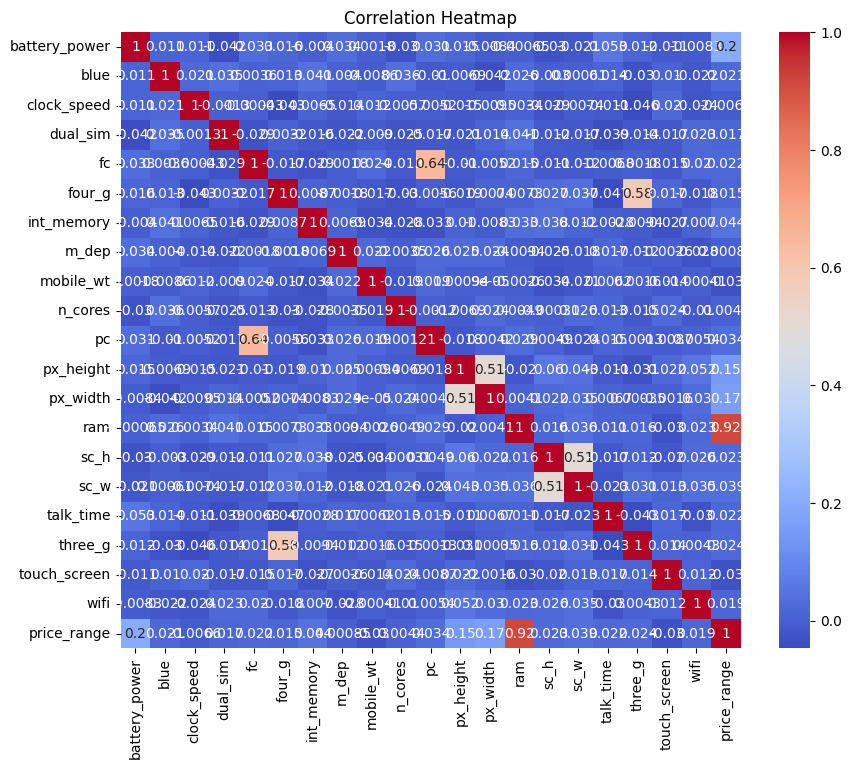

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

7. Feature & Target

In [9]:
X = data.drop(["price_range"], axis=1)
y = data["price_range"]

8. MODEL INITIALIZATION

In [10]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    random_state=42
)

9. FIRST SPLIT (80:20)

In [11]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train1, y_train1)
pred1 = model.predict(X_test1)

acc1 = accuracy_score(y_test1, pred1)

print("\n===== 80:20 SPLIT RESULTS =====")
print("Accuracy:", acc1)
print("\nClassification Report:\n", classification_report(y_test1, pred1))
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train1, y_train1)
pred1 = model.predict(X_test1)

acc1 = accuracy_score(y_test1, pred1)

print("\n===== 80:20 SPLIT RESULTS =====")
print("Accuracy:", acc1)
print("\nClassification Report:\n", classification_report(y_test1, pred1))



===== 80:20 SPLIT RESULTS =====
Accuracy: 0.8425

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.89       105
           1       0.75      0.79      0.77        91
           2       0.74      0.86      0.79        92
           3       0.95      0.87      0.91       112

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.85      0.84      0.85       400


===== 80:20 SPLIT RESULTS =====
Accuracy: 0.8425

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.85      0.89       105
           1       0.75      0.79      0.77        91
           2       0.74      0.86      0.79        92
           3       0.95      0.87      0.91       112

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.85      0.84  

10. SECOND SPLIT (70:30)


===== 70:30 SPLIT RESULTS =====
Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88       151
           1       0.72      0.84      0.78       146
           2       0.78      0.73      0.76       148
           3       0.93      0.84      0.88       155

    accuracy                           0.82       600
   macro avg       0.83      0.82      0.82       600
weighted avg       0.83      0.82      0.83       600



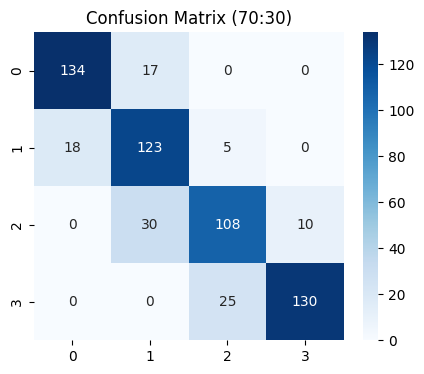

In [12]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model.fit(X_train2, y_train2)
pred2 = model.predict(X_test2)

acc2 = accuracy_score(y_test2, pred2)

print("\n===== 70:30 SPLIT RESULTS =====")
print("Accuracy:", acc2)
print("\nClassification Report:\n", classification_report(y_test2, pred2))

# Confusion Matrix
cm2 = confusion_matrix(y_test2, pred2)

plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (70:30)")
plt.show()

11. COMPARISON TABLE

In [13]:

results = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Accuracy": [acc1, acc2]
})

print("\n===== FINAL COMPARISON TABLE =====")
print(results)



===== FINAL COMPARISON TABLE =====
   Split  Accuracy
0  80:20    0.8425
1  70:30    0.8250


12. Feature Importance




Feature Importance:
           Feature  Importance
13            ram    0.728608
0   battery_power    0.126006
12       px_width    0.073089
11      px_height    0.054754
8       mobile_wt    0.010104
9         n_cores    0.004628
16      talk_time    0.002812
1            blue    0.000000
3        dual_sim    0.000000
2     clock_speed    0.000000
7           m_dep    0.000000
4              fc    0.000000
10             pc    0.000000
5          four_g    0.000000
6      int_memory    0.000000
14           sc_h    0.000000
15           sc_w    0.000000
17        three_g    0.000000
18   touch_screen    0.000000
19           wifi    0.000000


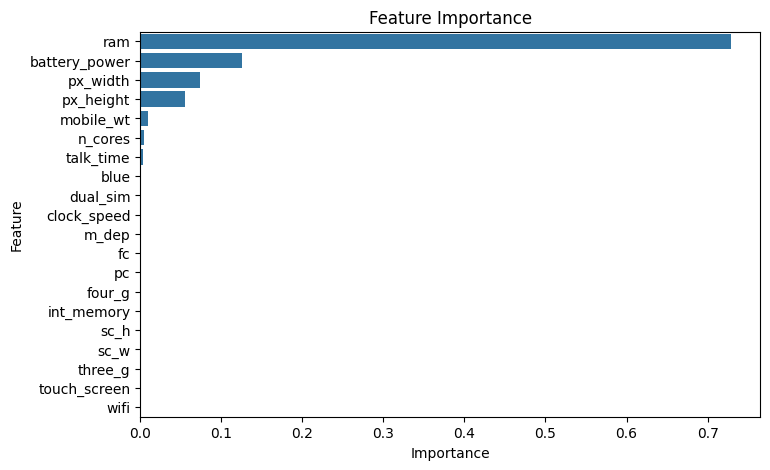

In [14]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()


13. Training vs Testing Accuracy

In [15]:
train_acc = model.score(X_train1, y_train1)
test_acc = model.score(X_test1, y_test1)

print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.9025
Testing Accuracy: 0.8275


14. Sample Prediction

In [16]:
sample = X_test1.iloc[0].values.reshape(1, -1)
print("\nSample Prediction:", model.predict(sample))



Sample Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


15. Final Output

In [17]:
print("\nDecision Tree Model Completed Successfully")
print("Comparison between different train-test splits completed")


Decision Tree Model Completed Successfully
Comparison between different train-test splits completed
